Using device: cpu

Training ResNet50...


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/2
----------
Train Loss: 0.5288 Acc: 0.7850
Val Loss: 21.7453 Acc: 0.5215

Epoch 2/2
----------
Train Loss: 0.3046 Acc: 0.8785
Val Loss: 0.4316 Acc: 0.8766

Training complete in 2m 32s
Best val Acc: 0.8766

Classification Report for ResNet50:
                 precision    recall  f1-score   support

Alopecia Areata       0.97      0.80      0.88       291
   Normal hairs       0.80      0.97      0.88       244

       accuracy                           0.88       535
      macro avg       0.89      0.88      0.88       535
   weighted avg       0.89      0.88      0.88       535



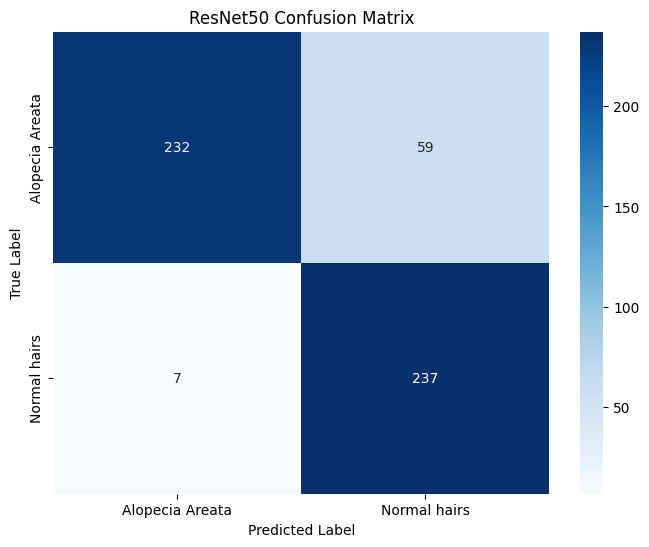

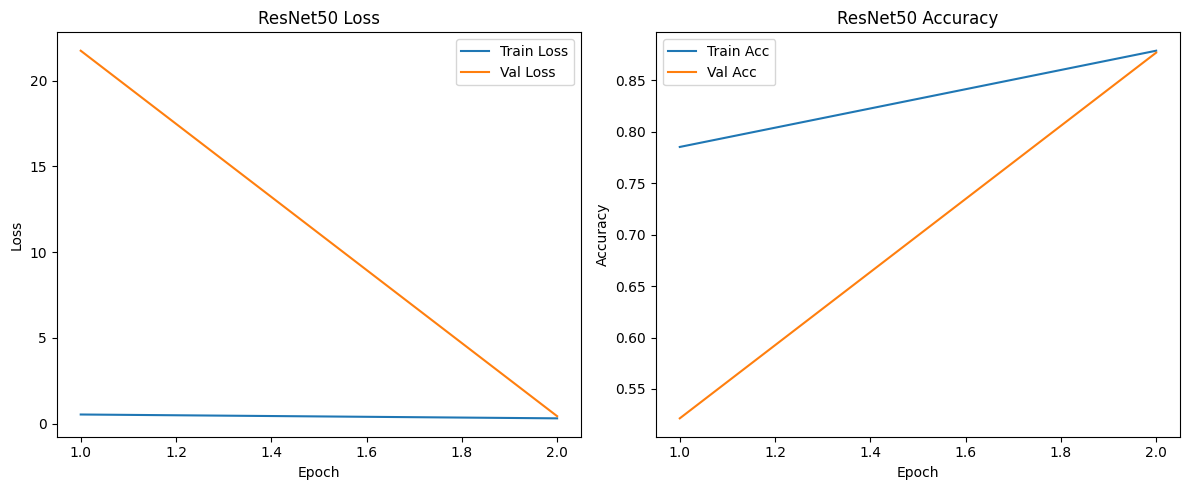


Training DenseNet121...

Epoch 1/2
----------


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 0.3760 Acc: 0.8374
Val Loss: 0.2779 Acc: 0.9215

Epoch 2/2
----------
Train Loss: 0.2246 Acc: 0.8953
Val Loss: 0.2796 Acc: 0.9121

Training complete in 2m 43s
Best val Acc: 0.9215

Classification Report for DenseNet121:
                 precision    recall  f1-score   support

Alopecia Areata       0.89      0.98      0.93       291
   Normal hairs       0.97      0.85      0.91       244

       accuracy                           0.92       535
      macro avg       0.93      0.92      0.92       535
   weighted avg       0.93      0.92      0.92       535



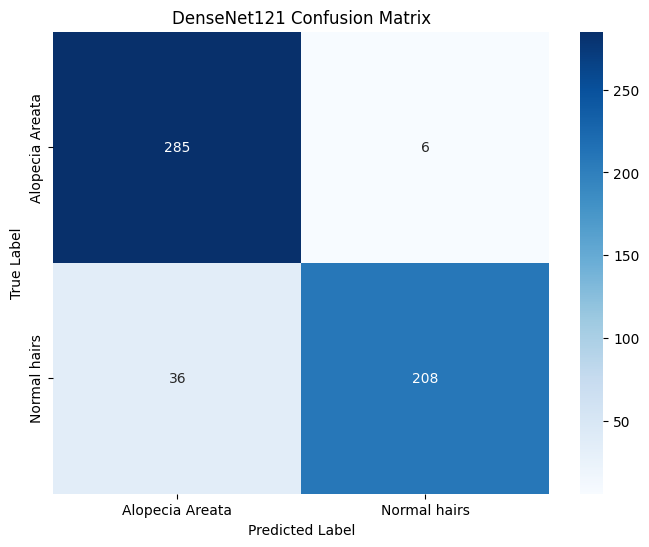

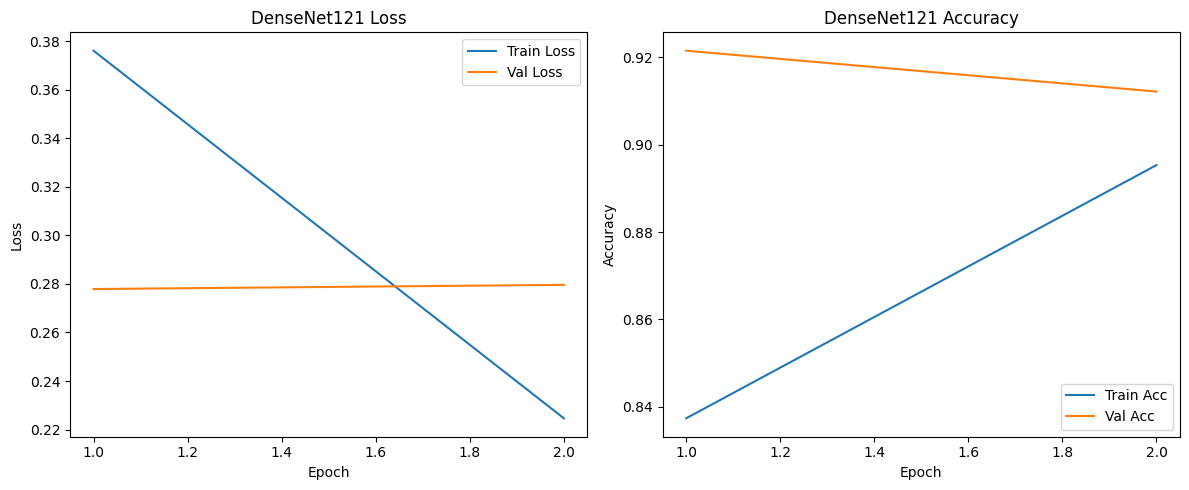


Training EfficientNetB0...

Epoch 1/2
----------


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train Loss: 0.2576 Acc: 0.8804
Val Loss: 0.0223 Acc: 0.9907

Epoch 2/2
----------
Train Loss: 0.1322 Acc: 0.9551
Val Loss: 0.0062 Acc: 1.0000

Training complete in 1m 54s
Best val Acc: 1.0000

Classification Report for EfficientNetB0:
                 precision    recall  f1-score   support

Alopecia Areata       1.00      1.00      1.00       291
   Normal hairs       1.00      1.00      1.00       244

       accuracy                           1.00       535
      macro avg       1.00      1.00      1.00       535
   weighted avg       1.00      1.00      1.00       535



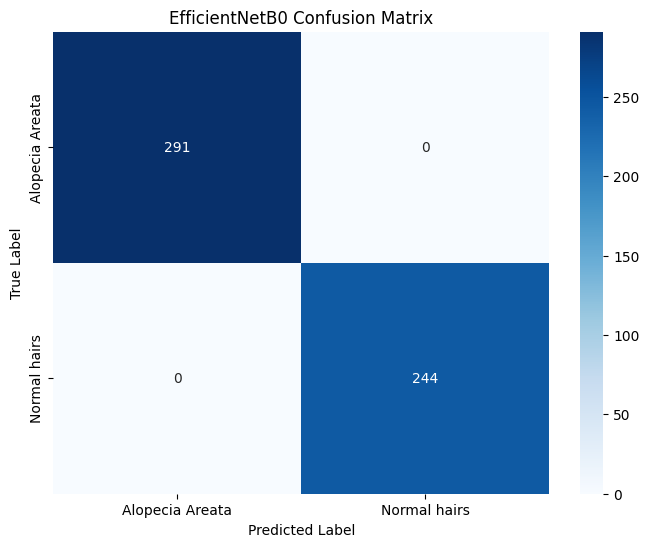

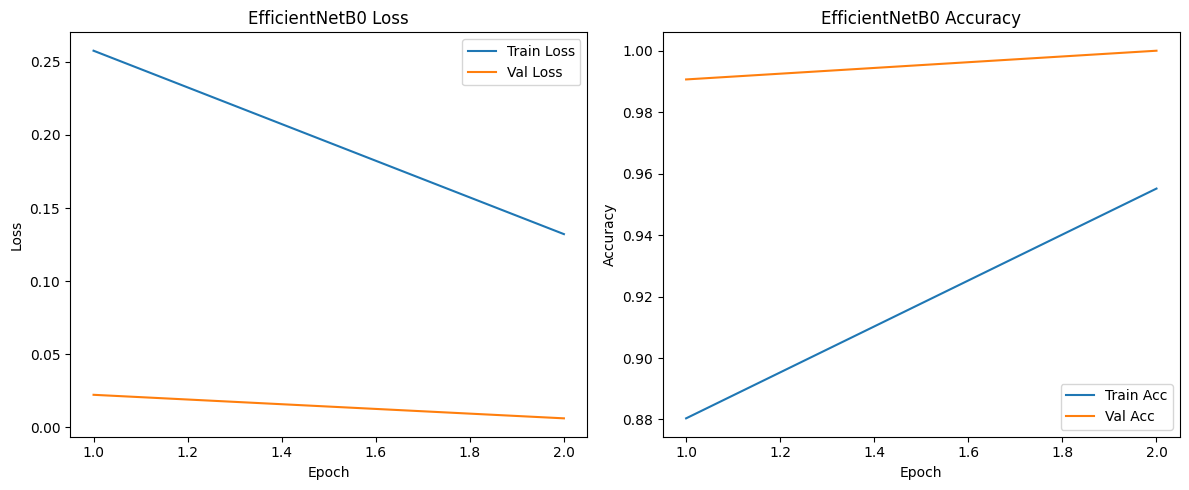

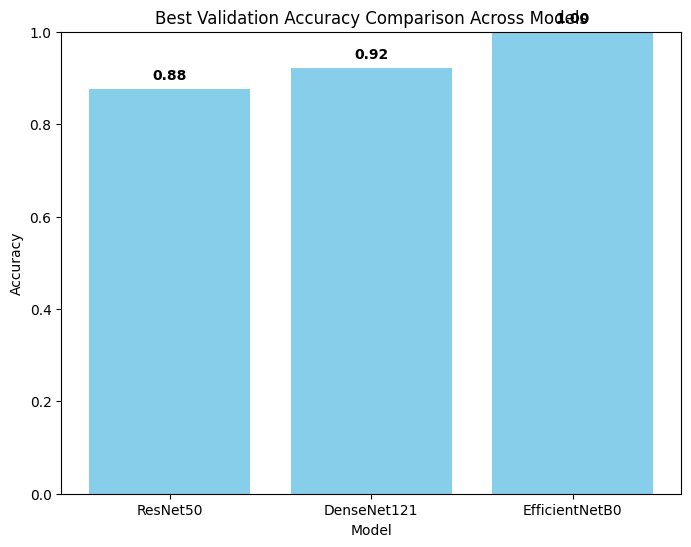


Selecting and saving the best model...
Best overall model: EfficientNetB0 with accuracy 1.0000
Best model saved to best_model.pth

Loading the best model for predictions...
Loaded model: EfficientNetB0


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Classification Report for the loaded best model (EfficientNetB0):
                 precision    recall  f1-score   support

Alopecia Areata       1.00      1.00      1.00       291
   Normal hairs       1.00      1.00      1.00       244

       accuracy                           1.00       535
      macro avg       1.00      1.00      1.00       535
   weighted avg       1.00      1.00      1.00       535



In [1]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# 1. Data Preparation
# ============================================

# Define data directories (change these to your dataset paths)
train_dir = r"F:\ABDUL\ABDUL 2024\HARLOSS_DL\OWN\Dataset\train"  # Example: train/class1, train/class2, ...
val_dir = r"F:\ABDUL\ABDUL 2024\HARLOSS_DL\OWN\Dataset\val"        # Example: val/class1, val/class2, ...

# Data augmentation and normalization for training
# Only normalization for validation
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
}

# Create datasets and dataloaders
image_datasets = {
    "train": datasets.ImageFolder(train_dir, transform=data_transforms["train"]),
    "val": datasets.ImageFolder(val_dir, transform=data_transforms["val"])
}
batch_size = 32
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x=="train"), num_workers=4)
    for x in ["train", "val"]
}
dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names = image_datasets["train"].classes
num_classes = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================
# 2. Training and Evaluation Functions
# ============================================

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # To store loss and accuracy history
    history = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        # Each epoch has a training and validation phase
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward pass (track history only in training)
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # deep copy the model if validation accuracy improved
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step()

    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(12, 5))
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

# ============================================
# 3. Model Builders
# ============================================

def get_resnet50():
    model = models.resnet50(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

def get_densenet121():
    model = models.densenet121(pretrained=True)
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, num_classes)
    return model

def get_efficientnet_b0():
    model = models.efficientnet_b0(pretrained=True)
    # For EfficientNet, the classifier is a Sequential: (Dropout, Linear)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    return model

# Dictionary of model builders
model_builders = {
    "ResNet50": get_resnet50,
    "DenseNet121": get_densenet121,
    "EfficientNetB0": get_efficientnet_b0,
}

# ============================================
# 4. Main: Training, Evaluation, and Saving Best Model
# ============================================

# Hyperparameters
num_epochs = 2  # Adjust as needed (use more epochs for better performance)
learning_rate = 0.001

# Dictionaries to store results and best overall model info
results_dict = {}
overall_best_acc = 0.0
overall_best_model_name = None
overall_best_state_dict = None

# Loop through each model
for model_name, build_model in model_builders.items():
    print("\n" + "=" * 40)
    print(f"Training {model_name}...")
    print("=" * 40)
    
    # Build model and move to device
    model = build_model().to(device)
    
    # Define loss, optimizer, and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    # Train the model
    model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)
    
    # Record best validation accuracy for this model
    best_val_acc = max(history["val_acc"])
    results_dict[model_name] = best_val_acc
    
    # Update overall best model if applicable
    if best_val_acc > overall_best_acc:
        overall_best_acc = best_val_acc
        overall_best_model_name = model_name
        overall_best_state_dict = copy.deepcopy(model.state_dict())
    
    # Evaluate on validation set
    y_true, y_pred = get_predictions(model, dataloaders["val"])
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Plot confusion matrix and training history
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, model_name)
    plot_history(history, model_name)

# ============================================
# 5. Overall Accuracy Visualization
# ============================================

plt.figure(figsize=(8, 6))
models_list = list(results_dict.keys())
accuracies = list(results_dict.values())
plt.bar(models_list, accuracies, color='skyblue')
plt.title("Best Validation Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# ============================================
# 6. Save Best Model, Load It, and Make Predictions
# ============================================

print("\n" + "=" * 40)
print("Selecting and saving the best model...")
print("=" * 40)
print(f"Best overall model: {overall_best_model_name} with accuracy {overall_best_acc:.4f}")

# Save the best model (including model name and state dict)
save_path = "best_model.pth"
torch.save({
    'model_name': overall_best_model_name,
    'state_dict': overall_best_state_dict
}, save_path)
print(f"Best model saved to {save_path}")

# Later... Load the saved model
print("\nLoading the best model for predictions...")
checkpoint = torch.load(save_path, map_location=device)
loaded_model_name = checkpoint['model_name']
print(f"Loaded model: {loaded_model_name}")

# Build the model architecture and load state dict
loaded_model = model_builders[loaded_model_name]().to(device)
loaded_model.load_state_dict(checkpoint['state_dict'])
loaded_model.eval()

# Make predictions on the validation set using the loaded model
y_true, y_pred = get_predictions(loaded_model, dataloaders["val"])
print(f"\nClassification Report for the loaded best model ({loaded_model_name}):")
print(classification_report(y_true, y_pred, target_names=class_names))
